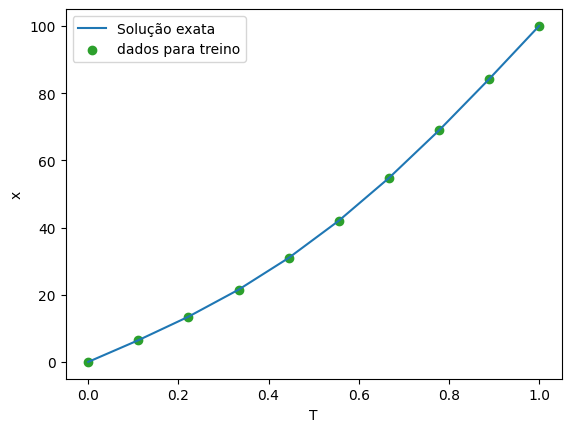

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "rede_para_PINN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 32)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 500/30000, Loss: 1597.882568359375, Data Loss: 1597.816162109375, Physics Loss: 0.06639785319566727
Epoch 1000/30000, Loss: 1221.430419921875, Data Loss: 1220.4990234375, Physics Loss: 0.9314329624176025
Epoch 1500/30000, Loss: 900.486328125, Data Loss: 894.9939575195312, Physics Loss: 5.492344379425049
Epoch 2000/30000, Loss: 698.0654907226562, Data Loss: 692.3665771484375, Physics Loss: 5.698892593383789
Epoch 2500/30000, Loss: 529.7256469726562, Data Loss: 526.4317016601562, Physics Loss: 3.293923854827881
Epoch 3000/30000, Loss: 381.4184875488281, Data Loss: 376.6422119140625, Physics Loss: 4.776288032531738
Epoch 3500/30000, Loss: 279.42022705078125, Data Loss: 273.3501892089844, Physics Loss: 6.070041656494141
Epoch 4000/30000, Loss: 204.13467407226562, Data Loss: 197.0736846923828, Physics Loss: 7.060981750488281
Epoch 4500/30000, Loss: 148.2574920654297, Data Loss: 140.56716918945312, Physics Loss: 7.690320014953613
Epoch 5000/30000, Loss: 107.11224365234375, Data Lo

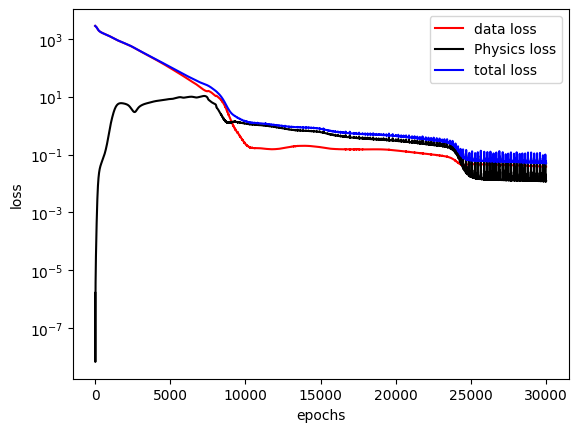

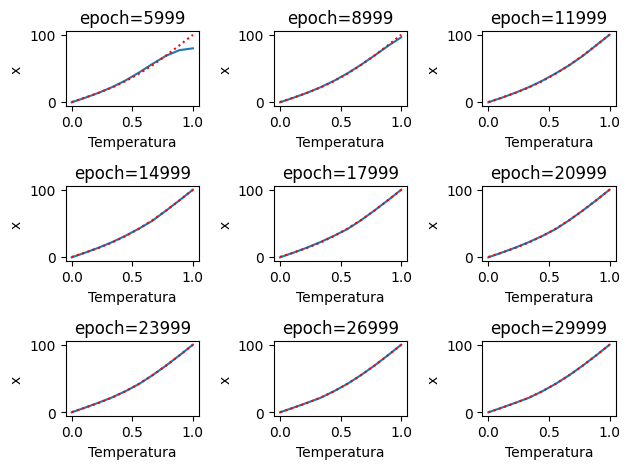

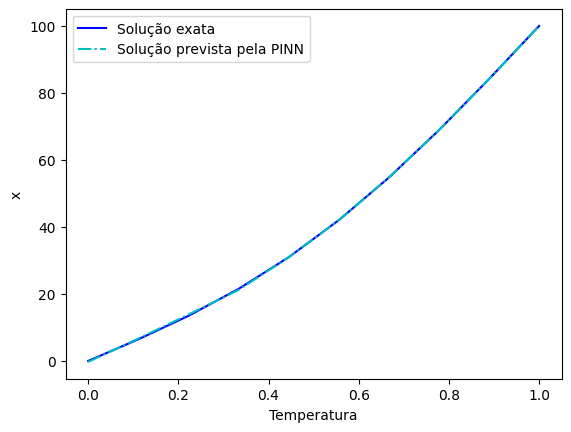

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import tensorflow as tf
import time


n_max = 500 #Número grande suficiente de iterações para calcular a somatória bem aproximada
#valores da função:
a = 1.412294
t = 0.11

def calculate_summation(n_max,x):
    summation = 0
    n = 1
    term = 1
    while n <= n_max:
        term = ((-1)**n)* (200 / (n * math.pi)) * math.sin(n * math.pi*x) * math.exp(-(t*a*(n * math.pi) ** 2))
        summation += term
        n += 1

    return summation


def solucao_exata(x):
    y = []
    for item in x:
        y.append((100*item) + calculate_summation(n_max,item))
    return y
#/
##res = funcao(x)
#plt.plot(x,res,'-o')
#plt.ylabel('Temperatura')
#plt.xlabel('x')
#plt.title('a = 1.304348 e t = 0.01')
#plt.show()
#/

# a função foi dividida em 11 pontos
#x = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
x = tf.linspace(0,1,10)
x = tf.cast(x, tf.float32) #transformar em float
x = tf.expand_dims(x, 1) # Adiciona uma nova dimensão de tamanho 1,
# transformando o tensor 1D em 2D (por exemplo, (10,) para (10, 1)).
# Isso é comum para inputs de redes neurais que esperam uma dimensão de batch.
y = solucao_exata(x) #calcular solução exata

# Pegar uma amostra a cada pontos até de 100 até 500
x_data = x[0:10:1]
y_data = y[0:10:1]

# Mostrar os pontos pegos e a solução exata
plt.figure()
plt.plot(x, y, label="Solução exata")
plt.scatter(x_data, y_data, color="tab:green", label="dados para treino")
plt.xlabel('T')
plt.ylabel('x')
plt.legend()
plt.show()

# Começar o treinamento
start_time = time.time()
# x da EDP, com 20 pontos
x_phys = tf.linspace(0,1,20)
x_phys = tf.cast(x_phys, tf.float32)
x_phys = tf.expand_dims(x_phys, 1)

#hiperparametros
tf.random.set_seed(5) #fixa a semente para cada teste ser igual
learning_rate = 0.0005
epochs = 30000
k_phy_loss=(1e-4)

# Arquiteruta do modelo neural, usando o keras
input_dim = 1
hidden_dim = 32
hidden_dim2 = 32
output_dim = 1

model_keras=tf.keras.Sequential([
    tf.keras.layers.Dense(hidden_dim, input_dim=input_dim, use_bias=1,activation='tanh'),
    tf.keras.layers.Dense(hidden_dim2, activation='tanh'),
    tf.keras.layers.Dense(output_dim, activation='linear')
],name='rede_para_PINN')
print(model_keras.summary())

optimizer = tf.optimizers.Adam(learning_rate=learning_rate)
# Treina a rede:
continuos_y_pred=np.zeros((len(x),10))
continuos_epoch=np.zeros((10,1))
count=0
h_loss=[]
h_data_loss=[]
h_Phys_loss=[]
for epoch in range(epochs):
    batch_X = x_data
    batch_y = y_data
    with tf.GradientTape() as tape:
        yh = model_keras(batch_X) #calcula as saidas da rede nos pontos "experimentais"
        data_loss = tf.reduce_mean(tf.square(yh - batch_y))
        with tf.GradientTape() as t2:
          t2.watch(x_phys)
          with tf.GradientTape() as t1:
            t1.watch(x_phys)
            yhp = model_keras(x_phys) #calcula as saidas da rede nos pontos escolhidos para ajustar a EDO
          dx  = t1.gradient(yhp, x_phys)# calcula dy/dx que é igual a ds/dt
        dx2 = t2.gradient(dx, x_phys) # calcula d^2y/dx^2 que é igual a d^2s/dt^2
        # EDO: 1*d2s/dt2+2*ds/dt+20*s=0 where s(0)=0 and s'(0)=1
        physics = a*dx2
        Phys_loss=k_phy_loss*tf.reduce_mean(tf.square(physics))
        #loss = tf.math.exp(tf.math.log(Phys_loss) + tf.math.log(data_loss))
        loss = Phys_loss + data_loss
    gradients = tape.gradient(loss, model_keras.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model_keras.trainable_variables))
    h_loss.append(loss)
    h_data_loss.append(data_loss)
    h_Phys_loss.append(Phys_loss)

    if ((epoch+1)%500==0):
      print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.numpy()}, Data Loss: {data_loss.numpy()}, Physics Loss: {Phys_loss.numpy()}")
      if ((epoch+1)%(np.round(epochs/10))==0):
        temp_pred=model_keras(x)
        yh = model_keras(x)
        continuos_y_pred[:,count]=temp_pred[:,0]
        continuos_epoch[count]=epoch
        count=count+1
        #plot_result(x,y,x_data,y_data,yh)
print("--- %s seconds ---" % (time.time() - start_time))

plt.figure()
plt.plot(h_data_loss,'r',label='data loss');
plt.plot(h_Phys_loss,'k',label='Physics loss');
plt.plot(h_loss,'b',label='total loss');
plt.yscale('log')
plt.legend()
plt.xlabel('epochs');plt.ylabel('loss')

plt.figure()
for qq in range(0,9):
  plt.subplot(3,3,qq+1)
  plt.plot(x,continuos_y_pred[:,qq+1])
  plt.plot(x,y,'r:')
  plt.xlabel('Temperatura');plt.ylabel('x')
  plt.title('epoch='+str(int(continuos_epoch[qq+1,0])))
plt.tight_layout()

plt.figure()
plt.plot(x, y,'b', label="Solução exata")
plt.plot(x,continuos_y_pred[:,-1],'c-.', label="Solução prevista pela PINN")
plt.xlabel('Temperatura');plt.ylabel('x')
plt.legend()